Part I: Building a Basic NN

STEP 1

1. Importing necessary libraries

In [58]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns


2. Exploring dataset + Load the dataset (dataset.csv)

In [60]:
dataset = pd.read_csv("dataset.csv")

print("First 5 rows of dataset:")
print(dataset.head())

print("\nInfo:")
print(dataset.info())

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nStatistics:")
print(dataset.describe())


if 'target' in dataset.columns:
    print("\ntarget distribution:")
    print(dataset['target'].value_counts())
print(dataset.columns)



First 5 rows of dataset:
  f1   f2  f3  f4   f5    f6     f7  target
0  6  148  72  35    0  33.6  0.627       1
1  1   85  66  29    0  26.6  0.351       0
2  8  183  64   0    0  23.3  0.672       1
3  1   89  66  23   94  28.1  0.167       0
4  0  137  40  35  168  43.1  2.288       1

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   f1      766 non-null    object
 1   f2      766 non-null    object
 2   f3      766 non-null    int64 
 3   f4      766 non-null    object
 4   f5      766 non-null    object
 5   f6      766 non-null    object
 6   f7      766 non-null    object
 7   target  766 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 48.0+ KB
None

Missing values:
f1        0
f2        0
f3        0
f4        0
f5        0
f6        0
f7        0
target    0
dtype: int64

Statistics:
               f3      target
count  766.0000

 3. Handle invalid character entries

In [61]:
dataset = dataset.replace('?', np.nan)
for col in dataset.columns:
    if col != 'target':
        dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

dataset = dataset.dropna()
if dataset['target'].dtype == 'object':
    dataset['target'] = dataset['target'].astype('category').cat.codes


Visualization 1

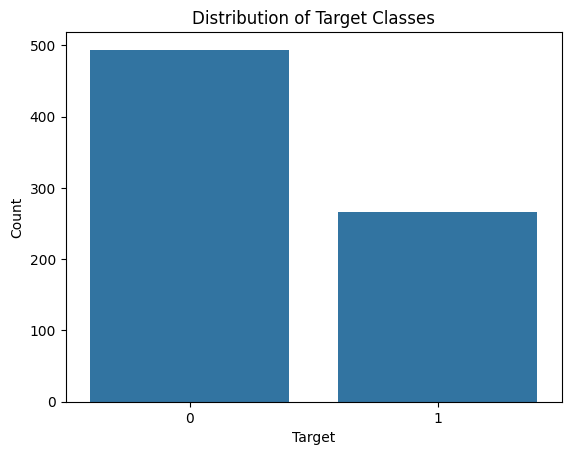

In [62]:
sns.countplot(data=dataset, x='target')
plt.title("Distribution of Target Classes")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


We have plotted the graph for target variable thats in range between 0 & 1 serves as the problem of binary classification. The graph shows how the values of target are distributed

Visualization 2

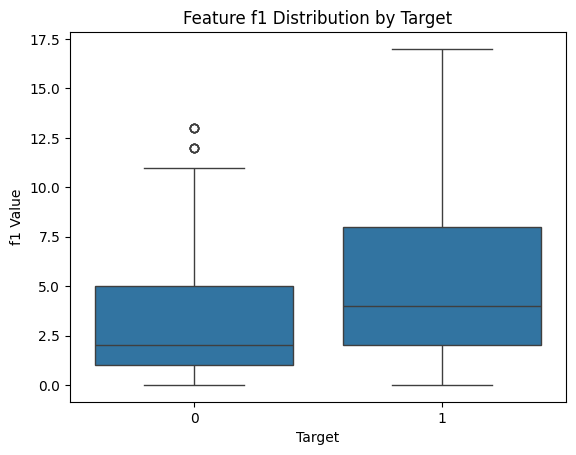

In [63]:
sns.boxplot(data=dataset, x='target', y='f1')
plt.title("Feature f1 Distribution by Target")
plt.xlabel("Target")
plt.ylabel("f1 Value")
plt.show()


Feature f1's median and interquartile range are noticeably higher for Target 1 than for Target 0, suggesting that f1 is positively correlated with the Target class and can help separate the groups, despite both distributions having outliers.

Visualization 3 

Using columns for pairplot: ['f1', 'f2', 'f3', 'f4']


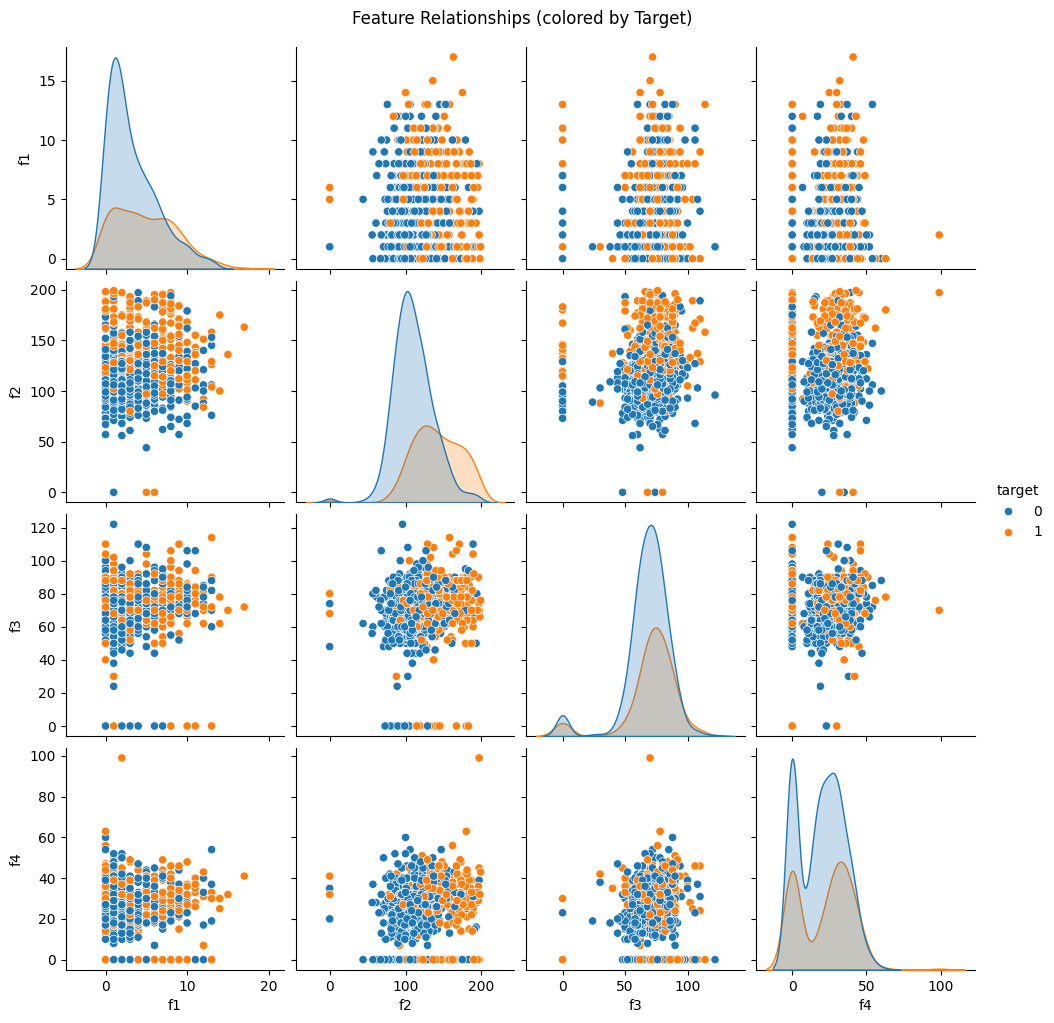

In [64]:
# Select only numeric columns automatically
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Just take a few numeric columns to visualize
selected_cols = numeric_cols[:4]

print("Using columns for pairplot:", selected_cols)

sns.pairplot(dataset, vars=selected_cols, hue='target')
plt.suptitle("Feature Relationships (colored by Target)", y=1.02)
plt.show()


The pair plot reveals that f1 and f4 show the strongest visual separation between Target 0 (blue) and Target 1 (orange) in their marginal distributions, while f2 and f3 exhibit substantial overlap across all relationships.

STEP 2

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

1. Preprocess the dataset

In [66]:

# 1. Separate features and target
X = dataset.drop('target', axis=1).astype(float).values
y = dataset['target'].values

# 2. Scale the numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from collections import Counter
print("Class distribution:", Counter(y))

# 4. Converting to tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

Class distribution: Counter({np.int64(0): 494, np.int64(1): 266})


Need to explain how we preprocess the data 

2. Split the dataset into training, testing and validation sets. 

In [67]:
# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Splitting the Validation & Test:  Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

# Converting to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


Train size: 532, Validation size: 114, Test size: 114


️3. Create PyTorch DataLoaders

In [68]:
batch_size = 64 #setting the batch size to 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


STEP 3

1. Defining the Neural Network 

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [70]:
class ImprovedNN(nn.Module):
    def __init__(self, input_size=7):
        super(ImprovedNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.fc4 = nn.Linear(16, 1)
        self.dropout = nn.Dropout(0.1)  # helps generalization
        
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x

# Initialize model and optimizer
model = ImprovedNN(input_size=X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0008, weight_decay=1e-5)
input_size = 7 
model.to(device)
# Loss function (Binary Cross Entropy Loss)
criterion = nn.BCELoss()


2. Model Summary

In [71]:
from torchinfo import summary

summary(model, input_size=(32, input_size))


Layer (type:depth-idx)                   Output Shape              Param #
ImprovedNN                               [32, 1]                   --
├─Linear: 1-1                            [32, 64]                  512
├─BatchNorm1d: 1-2                       [32, 64]                  128
├─Dropout: 1-3                           [32, 64]                  --
├─Linear: 1-4                            [32, 32]                  2,080
├─BatchNorm1d: 1-5                       [32, 32]                  64
├─Linear: 1-6                            [32, 16]                  528
├─BatchNorm1d: 1-7                       [32, 16]                  32
├─Linear: 1-8                            [32, 1]                   17
Total params: 3,361
Trainable params: 3,361
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.11
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.01
Estimated Total Size (MB): 0.07

Step 4: Training the Neural Network 

1. Define the loss function + Choose an optimizer and a learning rate. 

In [102]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

criterion = nn.BCELoss()

y_all = dataset['target'].values
class_w = compute_class_weight("balanced", classes=np.unique(y_all), y=y_all)
class_w = torch.tensor(class_w, dtype=torch.float32).to(device)
print("Class weights (for target classes 0,1):", class_w.cpu().numpy())

optimizer = optim.Adam(model.parameters(),  lr=0.001)


Class weights (for target classes 0,1): [0.7692308 1.4285715]


2. Train Model

In [105]:
num_epochs = 30
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(inputs)
        labels = labels.float()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = torch.round(outputs)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(inputs)
            labels = labels.float()
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.round(outputs)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Epoch [1/30] | Train Loss: 0.2173 | Val Loss: 0.8895 | Train Acc: 0.9211 | Val Acc: 0.6754
Epoch [2/30] | Train Loss: 0.1983 | Val Loss: 0.8875 | Train Acc: 0.9060 | Val Acc: 0.6754
Epoch [3/30] | Train Loss: 0.2485 | Val Loss: 0.8874 | Train Acc: 0.9004 | Val Acc: 0.6667
Epoch [4/30] | Train Loss: 0.1905 | Val Loss: 0.8945 | Train Acc: 0.9267 | Val Acc: 0.6754
Epoch [5/30] | Train Loss: 0.1914 | Val Loss: 0.9039 | Train Acc: 0.9267 | Val Acc: 0.6842
Epoch [6/30] | Train Loss: 0.1790 | Val Loss: 0.9084 | Train Acc: 0.9323 | Val Acc: 0.6842
Epoch [7/30] | Train Loss: 0.1994 | Val Loss: 0.8996 | Train Acc: 0.9323 | Val Acc: 0.6930
Epoch [8/30] | Train Loss: 0.2058 | Val Loss: 0.8997 | Train Acc: 0.9117 | Val Acc: 0.6667
Epoch [9/30] | Train Loss: 0.1953 | Val Loss: 0.9039 | Train Acc: 0.9361 | Val Acc: 0.6754
Epoch [10/30] | Train Loss: 0.1884 | Val Loss: 0.8771 | Train Acc: 0.9492 | Val Acc: 0.6842
Epoch [11/30] | Train Loss: 0.1730 | Val Loss: 0.8692 | Train Acc: 0.9361 | Val Acc: 0.68

3. Evaluation on test set

Accuracy: 77.19%
Precision: 0.72
Recall: 0.57
F1 Score: 0.64


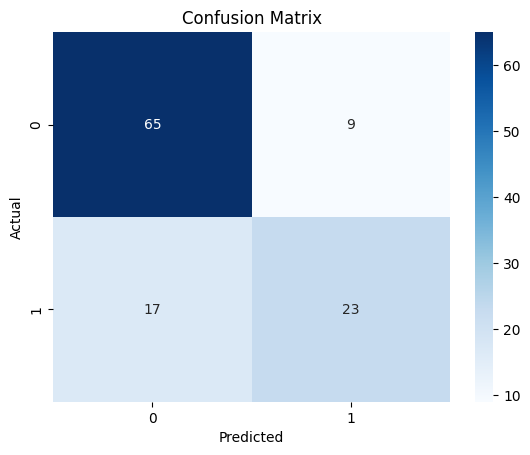

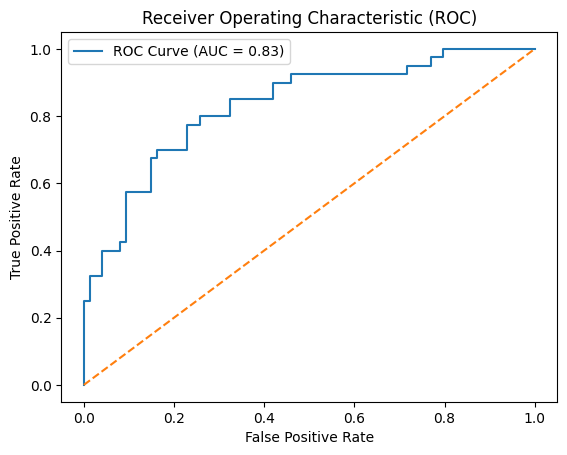

In [123]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = outputs.squeeze().cpu().numpy()
        preds = (outputs > 0.5).float().squeeze().cpu().numpy()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.show()


Test Accuracy: 74.56%
Test Loss: 0.5018


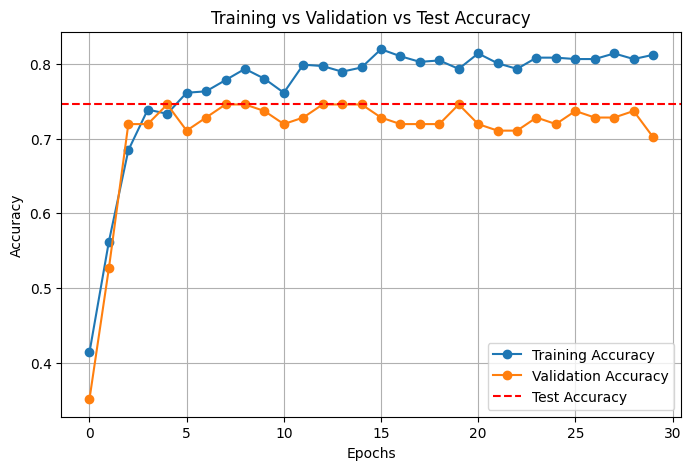

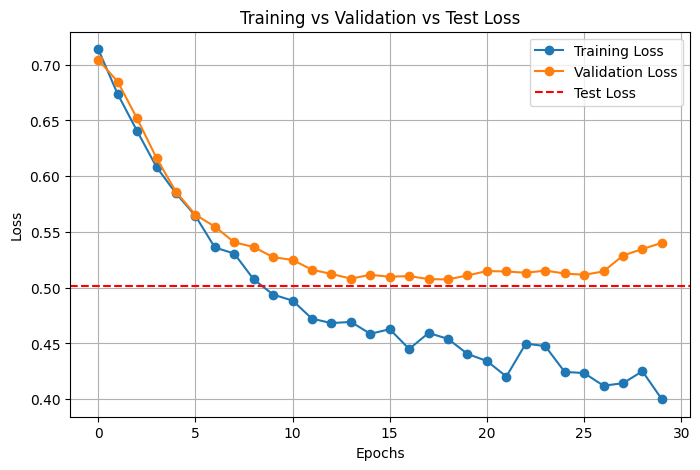

In [78]:
import matplotlib.pyplot as plt

#Evaluating on Test Data 
model.eval()
test_loss, correct, total = 0.0, 0, 0
criterion = nn.BCELoss()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
        outputs = model(inputs)
        labels = labels.float()
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        preds = torch.round(outputs)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_loss /= len(test_loader)
test_acc = correct / total

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

#Plotting the accuracy 
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label='Training Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.axhline(y=test_acc, color='r', linestyle='--', label='Test Accuracy')
plt.title('Training vs Validation vs Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#Plotting the Loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss')
plt.title('Training vs Validation vs Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
# Saving the model weights
torch.save(model.state_dict(), "best_model_weights.pth")
print("Model weights saved as best_model_weights.pth")
# Saving the entire model
torch.save(model, "best_model_full.pth")
print("Full model saved as best_model_full.pth")



✅ Model weights saved as best_model_weights.pth
✅ Full model saved as best_model_full.pth


Part II: Optimizing NN

1. Hyperparameter: Dropout Rate

In [107]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)

class ImprovedNN(nn.Module):
    def __init__(self, input_size=7, dropout_rate=0.2):
        super(ImprovedNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, 8)
        self.bn3 = nn.BatchNorm1d(8)
        self.fc4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x

#taking up the change of parameters as droupout rates
dropout_rates = [0.35, 0.4, 0.425, 0.45, 0.475, 0.5]
num_epochs = 30
learning_rate = 0.0015
batch_size = 64
num_runs = 3  # Run each dropout multiple times for getting stable accuracy
results = []

for dropout in dropout_rates:
    acc_list = []
    for run in range(num_runs):
        set_seed(42 + run)

        model = ImprovedNN(input_size=X_train.shape[1], dropout_rate=dropout).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.BCELoss()

        # Training loop for n-epochs
        for epoch in range(num_epochs):
            model.train()
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Evaluating the model on test set
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
                outputs = model(inputs)
                preds = torch.round(outputs)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        acc_list.append(correct / total * 100)

    avg_acc = np.mean(acc_list)
    results.append((dropout, avg_acc))
    print(f"Dropout: {dropout}, Average Test Accuracy: {avg_acc:.2f}%")

# Show results in a table
import pandas as pd
df_results = pd.DataFrame(results, columns=['Dropout Rate', 'Avg Test Accuracy (%)'])
print(df_results)


Dropout: 0.35, Average Test Accuracy: 75.73%
Dropout: 0.4, Average Test Accuracy: 75.44%
Dropout: 0.425, Average Test Accuracy: 76.32%
Dropout: 0.45, Average Test Accuracy: 76.32%
Dropout: 0.475, Average Test Accuracy: 75.44%
Dropout: 0.5, Average Test Accuracy: 75.73%
   Dropout Rate  Avg Test Accuracy (%)
0         0.350              75.730994
1         0.400              75.438596
2         0.425              76.315789
3         0.450              76.315789
4         0.475              75.438596
5         0.500              75.730994


2. Hyperparameter: Learning Rate

In [108]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)

class ImprovedNN(nn.Module):
    def __init__(self, input_size=7, dropout_rate=0.0044):
        super(ImprovedNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, 8)
        self.bn3 = nn.BatchNorm1d(8)
        self.fc4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x

# Taking up thechange of parameters as learning_rates
learning_rates = [0.0015, 0.002, 0.0025, 0.003, 0.0035]
num_epochs = 30
batch_size = 64
num_runs = 3 
dropout_rate = 0.425 # fixed best dropout from previous tuning

results = []

for lr in learning_rates:
    acc_list = []
    for run in range(num_runs):
        set_seed(42 + run) 

        model = ImprovedNN(input_size=X_train.shape[1], dropout_rate=dropout_rate).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.BCELoss()

        # Training loop for n-epochs
        for epoch in range(num_epochs):
            model.train()
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Evaluation on test set
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
                outputs = model(inputs)
                preds = torch.round(outputs)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        acc_list.append(correct / total * 100)

    avg_acc = np.mean(acc_list)
    results.append((lr, avg_acc))
    print(f"Learning Rate: {lr}, Average Test Accuracy: {avg_acc:.2f}%")

# Show results in a table
df_results = pd.DataFrame(results, columns=['Learning Rate', 'Avg Test Accuracy (%)'])
print("\nLearning Rate Tuning Results:")
print(df_results)


Learning Rate: 0.0015, Average Test Accuracy: 76.32%
Learning Rate: 0.002, Average Test Accuracy: 76.90%
Learning Rate: 0.0025, Average Test Accuracy: 75.73%
Learning Rate: 0.003, Average Test Accuracy: 76.02%
Learning Rate: 0.0035, Average Test Accuracy: 76.32%

Learning Rate Tuning Results:
   Learning Rate  Avg Test Accuracy (%)
0         0.0015              76.315789
1         0.0020              76.900585
2         0.0025              75.730994
3         0.0030              76.023392
4         0.0035              76.315789


In [109]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)

class ImprovedNN(nn.Module):
    def __init__(self, input_size=7, dropout_rate=0.0044):
        super(ImprovedNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, 8)
        self.bn3 = nn.BatchNorm1d(8)
        self.fc4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x

# taking up the change of parameters as epcohs
epoch_values = [20, 25, 30, 35, 40] 
learning_rate = 0.002
batch_size = 64
num_runs = 3 
dropout_rate = 0.425  # fixed best dropout

results = []

for num_epochs in epoch_values:
    acc_list = []
    for run in range(num_runs):
        set_seed(42 + run) 

        model = ImprovedNN(input_size=X_train.shape[1], dropout_rate=dropout_rate).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.BCELoss()

        # Training loop
        for epoch in range(num_epochs):
            model.train()
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Evaluation on test set
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
                outputs = model(inputs)
                preds = torch.round(outputs)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        acc_list.append(correct / total * 100)

    avg_acc = np.mean(acc_list)
    results.append((num_epochs, avg_acc))
    print(f"Epochs: {num_epochs}, Average Test Accuracy: {avg_acc:.2f}%")

# Show results in a table
df_results = pd.DataFrame(results, columns=['Epochs', 'Avg Test Accuracy (%)'])
print("\nEpoch Tuning Results:")
print(df_results)


Epochs: 20, Average Test Accuracy: 75.44%
Epochs: 25, Average Test Accuracy: 76.90%
Epochs: 30, Average Test Accuracy: 76.90%
Epochs: 35, Average Test Accuracy: 76.32%
Epochs: 40, Average Test Accuracy: 76.02%

Epoch Tuning Results:
   Epochs  Avg Test Accuracy (%)
0      20              75.438596
1      25              76.900585
2      30              76.900585
3      35              76.315789
4      40              76.023392


GIVE ANALYSIS ON BEST MODEL 

In [110]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import time

# Fix random seeds
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)

class BaseNN(nn.Module):
    def __init__(self, input_size=7, dropout_rate=0.425):
        super(BaseNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, 8)
        self.bn3 = nn.BatchNorm1d(8)
        self.fc4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x

learning_rate = 0.002
dropout_rate = 0.425
num_epochs = 25
batch_size = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
test_ds = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float())
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size)

set_seed(42)
model = BaseNN(input_size=X_train.shape[1], dropout_rate=dropout_rate).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.BCELoss()

start_time = time.time()
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Evaluate on test set
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
            outputs = model(inputs)
            preds = torch.round(outputs)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total * 100
    test_accuracies.append(acc)
    train_losses.append(epoch_loss / len(train_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss/len(train_loader):.4f} - Test Accuracy: {acc:.2f}%")

end_time = time.time()
training_time = end_time - start_time

print(f"\nBase Model Training Complete!")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
print(f"Total Training Time: {training_time:.2f} seconds")

# ==============================
# Save the Base Model
# ==============================
torch.save(model.state_dict(), "base_model_weights.pth")
torch.save(model, "base_model_full.pth")
print("Base model saved as base_model_weights.pth and base_model_full.pth")




Epoch 1/25 - Loss: 0.6426 - Test Accuracy: 64.91%
Epoch 2/25 - Loss: 0.6047 - Test Accuracy: 73.68%
Epoch 3/25 - Loss: 0.5805 - Test Accuracy: 74.56%
Epoch 4/25 - Loss: 0.5643 - Test Accuracy: 77.19%
Epoch 5/25 - Loss: 0.5445 - Test Accuracy: 77.19%
Epoch 6/25 - Loss: 0.5371 - Test Accuracy: 77.19%
Epoch 7/25 - Loss: 0.5167 - Test Accuracy: 77.19%
Epoch 8/25 - Loss: 0.5184 - Test Accuracy: 76.32%
Epoch 9/25 - Loss: 0.5048 - Test Accuracy: 75.44%
Epoch 10/25 - Loss: 0.4957 - Test Accuracy: 75.44%
Epoch 11/25 - Loss: 0.5053 - Test Accuracy: 75.44%
Epoch 12/25 - Loss: 0.4880 - Test Accuracy: 75.44%
Epoch 13/25 - Loss: 0.4887 - Test Accuracy: 75.44%
Epoch 14/25 - Loss: 0.4799 - Test Accuracy: 75.44%
Epoch 15/25 - Loss: 0.4746 - Test Accuracy: 75.44%
Epoch 16/25 - Loss: 0.4924 - Test Accuracy: 75.44%
Epoch 17/25 - Loss: 0.4817 - Test Accuracy: 75.44%
Epoch 18/25 - Loss: 0.4637 - Test Accuracy: 75.44%
Epoch 19/25 - Loss: 0.4930 - Test Accuracy: 75.44%
Epoch 20/25 - Loss: 0.4703 - Test Accura

In [115]:
from torch.utils.data import random_split

# Split train data into train + val
val_size = int(0.2 * len(train_ds))
train_size = len(train_ds) - val_size
train_ds, val_ds = random_split(train_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)


In [116]:
from torch.optim.lr_scheduler import StepLR
import copy
import time

set_seed(42)
model = BaseNN(input_size=X_train.shape[1], dropout_rate=dropout_rate).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)   # Reduce LR by half every 5 epochs
criterion = nn.BCELoss()

best_val_acc = 0
best_weights = copy.deepcopy(model.state_dict())
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
            preds = torch.round(model(inputs))
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total * 100
    print(f"Epoch {epoch+1} | LR: {scheduler.get_last_lr()[0]:.6f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())

end_time = time.time()
print(f"Model 1 (LR Scheduler) Best Val Acc: {best_val_acc:.2f}% | Time: {end_time-start_time:.2f}s")
torch.save(best_weights, "model1_scheduler.pth")


Epoch 1 | LR: 0.002000 | Val Acc: 72.94%
Epoch 2 | LR: 0.002000 | Val Acc: 72.94%
Epoch 3 | LR: 0.002000 | Val Acc: 78.82%
Epoch 4 | LR: 0.002000 | Val Acc: 82.35%
Epoch 5 | LR: 0.001000 | Val Acc: 82.35%
Epoch 6 | LR: 0.001000 | Val Acc: 82.35%
Epoch 7 | LR: 0.001000 | Val Acc: 82.35%
Epoch 8 | LR: 0.001000 | Val Acc: 82.35%
Epoch 9 | LR: 0.001000 | Val Acc: 82.35%
Epoch 10 | LR: 0.000500 | Val Acc: 83.53%
Epoch 11 | LR: 0.000500 | Val Acc: 83.53%
Epoch 12 | LR: 0.000500 | Val Acc: 83.53%
Epoch 13 | LR: 0.000500 | Val Acc: 83.53%
Epoch 14 | LR: 0.000500 | Val Acc: 83.53%
Epoch 15 | LR: 0.000250 | Val Acc: 83.53%
Epoch 16 | LR: 0.000250 | Val Acc: 83.53%
Epoch 17 | LR: 0.000250 | Val Acc: 83.53%
Epoch 18 | LR: 0.000250 | Val Acc: 83.53%
Epoch 19 | LR: 0.000250 | Val Acc: 83.53%
Epoch 20 | LR: 0.000125 | Val Acc: 83.53%
Epoch 21 | LR: 0.000125 | Val Acc: 83.53%
Epoch 22 | LR: 0.000125 | Val Acc: 83.53%
Epoch 23 | LR: 0.000125 | Val Acc: 83.53%
Epoch 24 | LR: 0.000125 | Val Acc: 83.53%
E

In [117]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, random_split
import time
import copy

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)

class BaseNN(nn.Module):
    def __init__(self, input_size=7, dropout_rate=0.425):
        super(BaseNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, 8)
        self.bn3 = nn.BatchNorm1d(8)
        self.fc4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x

batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create dataset and split into train/val/test
full_train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
val_size = int(0.2 * len(full_train_ds))
train_size = len(full_train_ds) - val_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float()), batch_size=batch_size)

learning_rate = 0.002
dropout_rate = 0.425
num_epochs = 50
patience = 5

#Initialize the model
set_seed(42)
model = BaseNN(input_size=X_train.shape[1], dropout_rate=dropout_rate).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.BCELoss()

#Setting up early stopping
best_val_acc = 0
best_weights = copy.deepcopy(model.state_dict())
counter = 0

train_losses = []
val_accuracies = []

start_time = time.time()

#Training Loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
            outputs = model(inputs)
            preds = torch.round(outputs)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total * 100
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early stopping logic
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

#Load the best model
model.load_state_dict(best_weights)
training_time = time.time() - start_time

#Evaluating the model on test set
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        preds = torch.round(model(inputs))
        correct += (preds == labels).sum().item()
        total += labels.size(0)
test_acc = correct / total * 100

print(f"\nModel 2 (Early Stopping) Training Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Final Test Accuracy: {test_acc:.2f}%")
print(f"Total Training Time: {training_time:.2f} seconds")

# ==============================
# 10. Save Model
# ==============================
torch.save(model.state_dict(), "model2_earlystop.pth")
print("Saved as model2_earlystop.pth")




Epoch [1/50] | Train Loss: 0.6416 | Val Acc: 67.92%
Epoch [2/50] | Train Loss: 0.6361 | Val Acc: 70.75%
Epoch [3/50] | Train Loss: 0.6048 | Val Acc: 76.42%
Epoch [4/50] | Train Loss: 0.5772 | Val Acc: 77.36%
Epoch [5/50] | Train Loss: 0.5754 | Val Acc: 78.30%
Epoch [6/50] | Train Loss: 0.5519 | Val Acc: 79.25%
Epoch [7/50] | Train Loss: 0.5500 | Val Acc: 79.25%
Epoch [8/50] | Train Loss: 0.5349 | Val Acc: 79.25%
Epoch [9/50] | Train Loss: 0.5230 | Val Acc: 79.25%
Epoch [10/50] | Train Loss: 0.5154 | Val Acc: 79.25%
Epoch [11/50] | Train Loss: 0.5174 | Val Acc: 79.25%
Early stopping triggered at epoch 11

Model 2 (Early Stopping) Training Complete!
Best Validation Accuracy: 79.25%
Final Test Accuracy: 77.19%
Total Training Time: 0.48 seconds
Saved as model2_earlystop.pth


In [118]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.model_selection import KFold
import numpy as np

class BaseNN(nn.Module):
    def __init__(self, input_size=7, dropout_rate=0.425):
        super(BaseNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, 8)
        self.bn3 = nn.BatchNorm1d(8)
        self.fc4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x



X = torch.tensor(X_train).float()
y = torch.tensor(y_train).float()
dataset = TensorDataset(X, y)


k_folds = 5 #Number of folds
num_epochs = 25
batch_size = 64
learning_rate = 0.002
dropout_rate = 0.425
criterion = nn.BCELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#K-Fold Setup
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_results = {}

for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset)):
    print(f"\n===== Fold {fold+1} / {k_folds} =====")

    # Subset for current fold
    train_subsampler = Subset(dataset, train_idx)
    val_subsampler = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subsampler, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subsampler, batch_size=batch_size, shuffle=False)

    # Create new model for each fold
    model = BaseNN(input_size=X.shape[1], dropout_rate=dropout_rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                preds = torch.round(outputs)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        print(f"Epoch {epoch+1}/{num_epochs} - Val Acc: {val_acc:.4f}")

    # Save results for this fold
    fold_results[fold] = val_acc
    print(f"Fold {fold+1} Final Accuracy: {val_acc:.4f}")


print("\n=== K-Fold Cross Validation Results ===")
for fold, acc in fold_results.items():
    print(f"Fold {fold+1}: {acc:.4f}")
print(f"\nAverage Validation Accuracy: {np.mean(list(fold_results.values())):.4f}")

torch.save(model.state_dict(), "model3_kfold.pth")
print("\nK-Fold model saved as model3_kfold.pth")



===== Fold 1 / 5 =====
Epoch 1/25 - Val Acc: 0.7009
Epoch 2/25 - Val Acc: 0.7103
Epoch 3/25 - Val Acc: 0.7664
Epoch 4/25 - Val Acc: 0.7757
Epoch 5/25 - Val Acc: 0.7944
Epoch 6/25 - Val Acc: 0.7944
Epoch 7/25 - Val Acc: 0.7850
Epoch 8/25 - Val Acc: 0.7850
Epoch 9/25 - Val Acc: 0.7850
Epoch 10/25 - Val Acc: 0.7944
Epoch 11/25 - Val Acc: 0.7664
Epoch 12/25 - Val Acc: 0.7664
Epoch 13/25 - Val Acc: 0.7664
Epoch 14/25 - Val Acc: 0.7757
Epoch 15/25 - Val Acc: 0.7757
Epoch 16/25 - Val Acc: 0.7944
Epoch 17/25 - Val Acc: 0.7944
Epoch 18/25 - Val Acc: 0.7757
Epoch 19/25 - Val Acc: 0.7664
Epoch 20/25 - Val Acc: 0.7944
Epoch 21/25 - Val Acc: 0.7570
Epoch 22/25 - Val Acc: 0.7570
Epoch 23/25 - Val Acc: 0.7570
Epoch 24/25 - Val Acc: 0.7757
Epoch 25/25 - Val Acc: 0.7757
Fold 1 Final Accuracy: 0.7757

===== Fold 2 / 5 =====
Epoch 1/25 - Val Acc: 0.3645
Epoch 2/25 - Val Acc: 0.5701
Epoch 3/25 - Val Acc: 0.6916
Epoch 4/25 - Val Acc: 0.7103
Epoch 5/25 - Val Acc: 0.7196
Epoch 6/25 - Val Acc: 0.7570
Epoch 7

In [122]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import time
import copy

# -----------------------------
# 1. Set Seed
# -----------------------------
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)

# -----------------------------
# 2. Define Model
# -----------------------------
class BaseNN(nn.Module):
    def __init__(self, input_size=7, dropout_rate=0.425):
        super(BaseNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, 8)
        self.bn3 = nn.BatchNorm1d(8)
        self.fc4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x

# -----------------------------
# 3. Prepare Data
# -----------------------------
batch_size = 64
accumulation_steps = 4  # Number of steps to accumulate gradients
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
val_size = int(0.2 * len(full_train_ds))
train_size = len(full_train_ds) - val_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float()), batch_size=batch_size)

# -----------------------------
# 4. Initialize Model
# -----------------------------
learning_rate = 0.002
num_epochs = 50
dropout_rate = 0.425
criterion = nn.BCELoss()

model = BaseNN(input_size=X_train.shape[1], dropout_rate=dropout_rate).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# -----------------------------
# 5. Gradient Accumulation Training Loop
# -----------------------------
best_val_acc = 0
best_weights = copy.deepcopy(model.state_dict())
train_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss = loss / accumulation_steps  # scale loss
        loss.backward()
        running_loss += loss.item()
        
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
            optimizer.step()
            optimizer.zero_grad()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
            outputs = model(inputs)
            preds = torch.round(outputs)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total * 100
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())

# Load best model weights
model.load_state_dict(best_weights)
training_time = time.time() - start_time

# -----------------------------
# 6. Evaluate on Test Set
# -----------------------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        preds = torch.round(model(inputs))
        correct += (preds == labels).sum().item()
        total += labels.size(0)
test_acc = correct / total * 100

print(f"\n✅ Gradient Accumulation Model Training Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Final Test Accuracy: {test_acc:.2f}%")
print(f"⏱️ Total Training Time: {training_time:.2f} seconds")

# -----------------------------
# 7. Save Model
# -----------------------------
torch.save(model.state_dict(), "model4_grad_accum.pth")
print("💾 Saved as model4_grad_accum.pth")


Epoch [1/50] | Train Loss: 0.1675 | Val Acc: 67.92%
Epoch [2/50] | Train Loss: 0.1644 | Val Acc: 72.64%
Epoch [3/50] | Train Loss: 0.1599 | Val Acc: 73.58%
Epoch [4/50] | Train Loss: 0.1581 | Val Acc: 72.64%
Epoch [5/50] | Train Loss: 0.1577 | Val Acc: 74.53%
Epoch [6/50] | Train Loss: 0.1536 | Val Acc: 77.36%
Epoch [7/50] | Train Loss: 0.1511 | Val Acc: 76.42%
Epoch [8/50] | Train Loss: 0.1515 | Val Acc: 77.36%
Epoch [9/50] | Train Loss: 0.1499 | Val Acc: 77.36%
Epoch [10/50] | Train Loss: 0.1468 | Val Acc: 77.36%
Epoch [11/50] | Train Loss: 0.1464 | Val Acc: 76.42%
Epoch [12/50] | Train Loss: 0.1456 | Val Acc: 76.42%
Epoch [13/50] | Train Loss: 0.1436 | Val Acc: 78.30%
Epoch [14/50] | Train Loss: 0.1419 | Val Acc: 78.30%
Epoch [15/50] | Train Loss: 0.1437 | Val Acc: 77.36%
Epoch [16/50] | Train Loss: 0.1411 | Val Acc: 80.19%
Epoch [17/50] | Train Loss: 0.1400 | Val Acc: 80.19%
Epoch [18/50] | Train Loss: 0.1358 | Val Acc: 80.19%
Epoch [19/50] | Train Loss: 0.1362 | Val Acc: 79.25%
Ep

We have used the following 4-Methods
1. Learning Rate Scheduler
2. Early Stopping
3. K-Folds 
4. Gradient Accumulation

Out of the following  4 methods we have achieved the highest accuracy using Early Stopping I.e. 79.25


Final Accuracy of the model is 77.19

In [120]:
import torch

# Load the Early Stopping model
model = BaseNN(input_size=X_train.shape[1], dropout_rate=0.425)
model.load_state_dict(torch.load("model2_earlystop.pth"))

torch.save(model.state_dict(), "final_best_model.pth")
torch.save(model, "final_best_model_full.pth")
print("Final best model saved as final_best_model.pth and final_best_model_full.pth")


Final best model saved as final_best_model.pth and final_best_model_full.pth


Final Best Model Test Accuracy: 77.19%


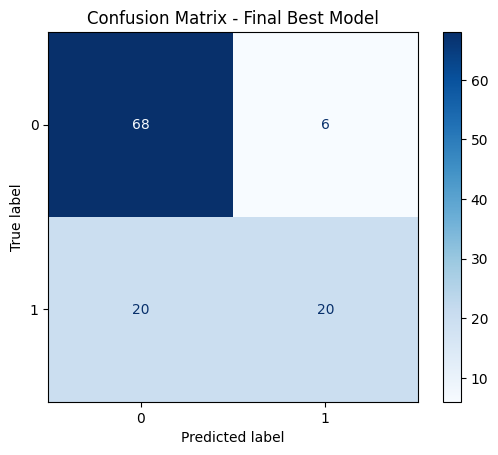

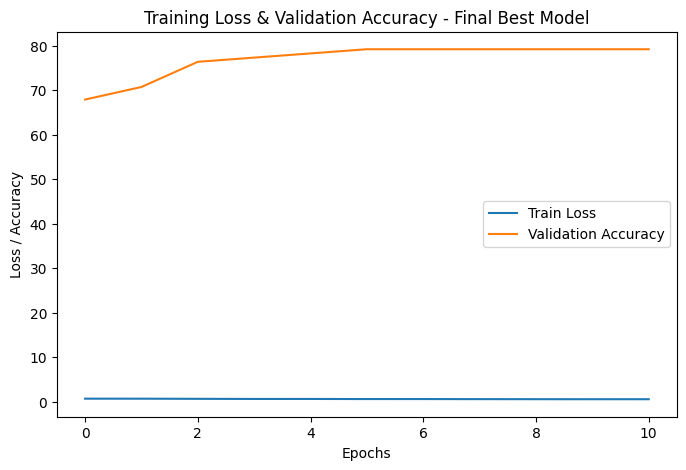

In [121]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Loading the final best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_model = BaseNN(input_size=X_train.shape[1], dropout_rate=0.425).to(device)
final_model.load_state_dict(torch.load("final_best_model.pth"))
final_model.eval()

#Evaluating on the test set
correct, total = 0, 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        outputs = final_model(inputs)
        preds = torch.round(outputs)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total * 100
print(f"Final Best Model Test Accuracy: {test_acc:.2f}%")

#Plotting Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Final Best Model")
plt.show()

#Plotting Training aionnd Validat
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.title("Training Loss & Validation Accuracy - Final Best Model")
plt.legend()
plt.show()
